In [27]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

In [28]:
rho, c, T, Omega, u_0, L, m = sp.symbols(['rho', 'c', 'T', 'Omega', 'u_0', 'L', 'm'])
C_1, C_2 = sp.symbols(['C_1', 'C_2'])
x, t = sp.symbols(['x', 't'])
k = sp.symbols('k')
k = sp.sqrt((Omega**2 * rho - c * sp.I * Omega) / T)


In [29]:
print(sp.I * sp.I)

-1


In [30]:
k

sqrt((Omega**2*rho - I*Omega*c)/T)

In [31]:
u_hat = C_1 * sp.exp(sp.I * k * x) + C_2 * sp.exp(-1 * sp.I * k * x)
du_hatdx = sp.diff(u_hat, x)

In [32]:
du_hatdx

I*C_1*sqrt((Omega**2*rho - I*Omega*c)/T)*exp(I*x*sqrt((Omega**2*rho - I*Omega*c)/T)) - I*C_2*sqrt((Omega**2*rho - I*Omega*c)/T)*exp(-I*x*sqrt((Omega**2*rho - I*Omega*c)/T))

In [33]:
eq_1 = sp.Eq(
    u_hat.subs({x:0}) - u_0,
    0
)

eq_2 = sp.Eq(
    T * du_hatdx.subs({x:L}),
    m * Omega**2 * u_hat.subs({x:L})
)

In [34]:
eq_1

Eq(C_1 + C_2 - u_0, 0)

In [35]:
eq_2

Eq(T*(I*C_1*sqrt((Omega**2*rho - I*Omega*c)/T)*exp(I*L*sqrt((Omega**2*rho - I*Omega*c)/T)) - I*C_2*sqrt((Omega**2*rho - I*Omega*c)/T)*exp(-I*L*sqrt((Omega**2*rho - I*Omega*c)/T))), Omega**2*m*(C_1*exp(I*L*sqrt((Omega**2*rho - I*Omega*c)/T)) + C_2*exp(-I*L*sqrt((Omega**2*rho - I*Omega*c)/T))))

In [36]:
sol = sp.linsolve([eq_1, eq_2], [C_1, C_2])

In [37]:
sol_C_1 = sp.simplify(list(sol)[0][0])
sol_C_2 = sp.simplify(list(sol)[0][1])

In [38]:
sol_u_hat = u_hat.subs({
    C_1 : sol_C_1,
    C_2 : sol_C_2
})

In [39]:
sol_u_hat

u_0*(-Omega**2*m + I*T*sqrt(Omega*(Omega*rho - I*c)/T))*exp(2*I*L*sqrt(Omega*(Omega*rho - I*c)/T))*exp(-I*x*sqrt((Omega**2*rho - I*Omega*c)/T))/(-Omega**2*m*exp(2*I*L*sqrt(Omega*(Omega*rho - I*c)/T)) + Omega**2*m + I*T*sqrt(Omega*(Omega*rho - I*c)/T)*exp(2*I*L*sqrt(Omega*(Omega*rho - I*c)/T)) + I*T*sqrt(Omega*(Omega*rho - I*c)/T)) + u_0*(Omega**2*m + I*T*sqrt(Omega*(Omega*rho - I*c)/T))*exp(I*x*sqrt((Omega**2*rho - I*Omega*c)/T))/(-Omega**2*m*exp(2*I*L*sqrt(Omega*(Omega*rho - I*c)/T)) + Omega**2*m + I*T*sqrt(Omega*(Omega*rho - I*c)/T)*exp(2*I*L*sqrt(Omega*(Omega*rho - I*c)/T)) + I*T*sqrt(Omega*(Omega*rho - I*c)/T))

In [54]:
# parameter values
variable_dict = {
    u_0 : 1,
    Omega : 2.5,
    T : 10**9,
    c : 10e4,
    L : 300,
    rho : 0.04,
    m : 600000
}

variable_dict_earthquake = {
    u_0 : 1,
    T : 10**9,
    #c : 10e3,
    L : 300,
    rho : 0.04,
    #m : 600000,
    x : 300
}

In [55]:
f_u_hat = sp.lambdify(x, sol_u_hat.subs(variable_dict), modules='numpy')

In [56]:
sol_u = sp.re(sol_u_hat * sp.exp(sp.I * Omega * t))

In [57]:
f_u = sp.lambdify((x, t), sol_u.subs(variable_dict), modules='numpy')

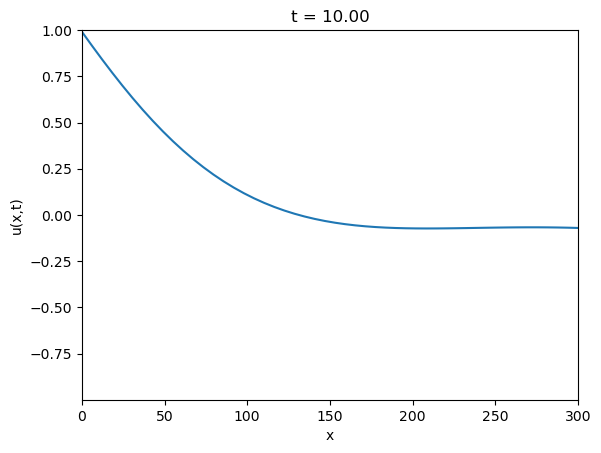

In [58]:
from matplotlib import animation
from IPython.display import HTML

# animation of f_u over ar_x and ar_t
ar_t = np.linspace(0, 10, 100)
ar_x = np.linspace(0, 300, 50)
data = np.array([f_u(ar_x, tval) for tval in ar_t])

fig, ax = plt.subplots()
line, = ax.plot(ar_x, data[0])
ax.set_xlim(ar_x.min(), ar_x.max())
ax.set_ylim(data.min(), data.max())
ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')

def update(i):
    line.set_ydata(data[i])
    ax.set_title(f"t = {ar_t[i]:.2f}")
    return (line,)

ani = animation.FuncAnimation(fig, update, frames=len(ar_t), interval=50, blit=True)

HTML(ani.to_jshtml())


In [45]:
f_uL_earthquake = sp.lambdify((Omega,m, c), sp.Abs(sol_u_hat).subs(variable_dict_earthquake), modules='numpy')

<lambdifygenerated-8>:2: RuntimeWarning: invalid value encountered in divide
  return abs((Omega**2*m - 10000*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c)))*exp(-300*1j*sqrt(4.0e-11*Omega**2 - 1/1000000000*1j*Omega*c))*exp((3/500)*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c)))/(-Omega**2*m*exp((3/500)*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c))) + Omega**2*m + 10000*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c))*exp((3/500)*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c))) + 10000*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c))) - (Omega**2*m + 10000*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c)))*exp(300*1j*sqrt(4.0e-11*Omega**2 - 1/1000000000*1j*Omega*c))/(-Omega**2*m*exp((3/500)*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c))) + Omega**2*m + 10000*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c))*exp((3/500)*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c))) + 10000*sqrt(10)*1j*sqrt(Omega*(0.04*Omega - 1j*c))))


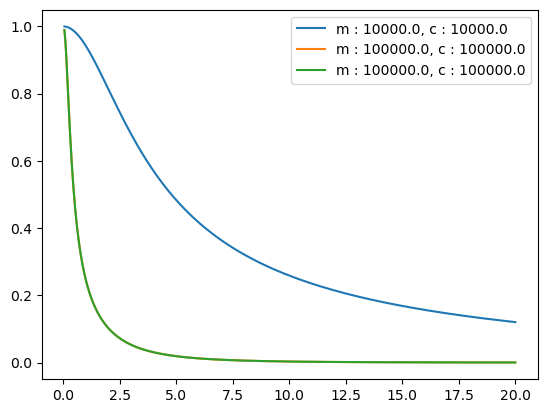

In [46]:

ar_Omega = np.linspace(0,20,500)
l_damping = [1e4, 1e5, 1e5]
l_mass    = [1e4, 1e5, 1e5]
for m_i, c_i in list(zip(l_mass, l_damping)):
    plt.plot(ar_Omega,f_uL_earthquake(ar_Omega, m_i, c_i), label=f'm : {m_i}, c : {c_i}')
plt.legend()


Text(0.5, 0, 'External Forcing Frequency [rad/s]')

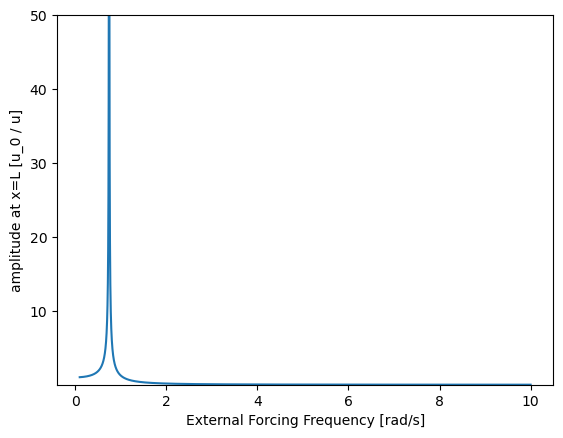

In [48]:
ar_Omega = np.linspace(0.1, 10, 10000)
plt.plot(ar_Omega,f_uL_earthquake(ar_Omega, 6*10**6, 100))
plt.ylim(0.001,50)
plt.ylabel('amplitude at x=L [u_0 / u]')
plt.xlabel('External Forcing Frequency [rad/s]') 
